<a href="https://colab.research.google.com/github/mayashah100/MEI-Data-Science-Project/blob/main/MEI_DataScienceCourse_Lesson4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEI Introduction to Data Science: Activity 4c - Exploring country data

# Introduction

In Lesson 3 activity 2 you used data to explore features of countries that are associated with higher life expectancy. In this activity you'll take that exploration further to investigate differences between high and low income economies, and how life expectancy has changed over time.

The activity uses the data from the MEI large data set (number 4) which gives demographic information about countries. For more information about the data see the short video at: https://mei.org.uk/introduction-to-data-science/large-data-sets/

## Problem

* ***What are the differences between high and low income economies?***
* ***How has life expectancy in high and low income economies changed since 1960?***

## Importing libraries and data

> Run the code to import the libraries and the data.

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
# import the data https://drive.google.com/file/d/1SLgCi2HMqdaKLowJiL_dVyLjKMOQBfEo/view?usp=drive_link
!gdown '1SLgCi2HMqdaKLowJiL_dVyLjKMOQBfEo'
world_data = pd.read_csv('../content/mei-lds-4.csv')
# check the data
world_data

Downloading...
From: https://drive.google.com/uc?id=1SLgCi2HMqdaKLowJiL_dVyLjKMOQBfEo
To: /content/mei-lds-4.csv
100% 27.8k/27.8k [00:00<00:00, 60.7MB/s]


,no,Country,Region,population,birth rate per 1000,death rate per 1000,median age,labor force,unemployment (%),GDP per capita (US$),physician density (physicians/1000 population),Health expenditure (% of GDP),Total area,Land borders,Life expectancy at birth 1960,Life expectancy at birth 1970,Life expectancy at birth 1980,Life expectancy at birth 1990,Life expectancy at birth 2000,Life expectancy at birth 2010
0,1,Algeria,"Africa, N",41657488,21.5,4.3,28.3,11820000.0,11.7,15200.0,1.83,7.2,2381740,Yes,46.14,50.37,58.20,66.73,70.29,74.68
1,2,Egypt,"Africa, N",99413317,28.8,4.5,23.9,29950000.0,12.2,12700.0,0.79,5.6,1001450,Yes,48.06,52.16,58.34,64.58,68.61,70.36
2,3,Libya,"Africa, N",6754507,17.2,3.7,29.4,1114000.0,30.0,9600.0,2.16,5.0,1759540,Yes,42.61,56.05,64.19,68.52,70.47,71.64
3,4,Morocco,"Africa, N",34314130,17.5,4.9,29.7,12000000.0,10.2,8600.0,0.73,5.9,446550,Yes,48.46,52.57,57.56,64.73,68.72,74.00
4,5,Sudan,"Africa, N",43120843,34.2,6.7,17.9,11920000.0,19.6,4300.0,0.41,8.4,1861484,Yes,48.19,52.23,54.25,55.50,58.43,62.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,232,Tokelau,Oceania,1285,NaN,NaN,NaN,440.0,NaN,1000.0,2.72,NaN,12,No,NaN,NaN,NaN,NaN,NaN,NaN
232,233,Tonga,Oceania,106398,21.8,4.9,23.3,33800.0,1.1,5900.0,0.52,5.2,747,No,61.40,64.88,67.48,69.60,70.81,72.17
233,234,Tuvalu,Oceania,11147,23.7,8.4,26.0,3615.0,NaN,3800.0,0.92,16.5,26,No,NaN,NaN,NaN,NaN,NaN,NaN
234,235,Vanuatu,Oceania,288037,23.5,4.0,22.3,115900.0,1.7,2700.0,0.17,5.0,12189,No,46.44,52.37,58.35,63.07,67.44,70.72


# Exploring the differences between high and low income countries

## Pre-processing the data

## Adding a new categorical feature
The World Bank defines a _High Income Economy_ as one having a GDP _per capita_ greater than \$12,376

> Run the code below to create a new categorical feature `Income category` which describes whether a country is a high income economy

In [ ]:
# if the GDP > 12376 then High, otherwise Low
world_data['Income category'] = (world_data['GDP per capita (US$)'] > 12376).map({True: "High", False: "Low"})

#check the data
world_data

,no,Country,Region,population,birth rate per 1000,death rate per 1000,median age,labor force,unemployment (%),GDP per capita (US$),...,Health expenditure (% of GDP),Total area,Land borders,Life expectancy at birth 1960,Life expectancy at birth 1970,Life expectancy at birth 1980,Life expectancy at birth 1990,Life expectancy at birth 2000,Life expectancy at birth 2010,Income category
0,1,Algeria,"Africa, N",41657488,21.5,4.3,28.3,11820000.0,11.7,15200.0,...,7.2,2381740,Yes,46.14,50.37,58.20,66.73,70.29,74.68,High
1,2,Egypt,"Africa, N",99413317,28.8,4.5,23.9,29950000.0,12.2,12700.0,...,5.6,1001450,Yes,48.06,52.16,58.34,64.58,68.61,70.36,High
2,3,Libya,"Africa, N",6754507,17.2,3.7,29.4,1114000.0,30.0,9600.0,...,5.0,1759540,Yes,42.61,56.05,64.19,68.52,70.47,71.64,Low
3,4,Morocco,"Africa, N",34314130,17.5,4.9,29.7,12000000.0,10.2,8600.0,...,5.9,446550,Yes,48.46,52.57,57.56,64.73,68.72,74.00,Low
4,5,Sudan,"Africa, N",43120843,34.2,6.7,17.9,11920000.0,19.6,4300.0,...,8.4,1861484,Yes,48.19,52.23,54.25,55.50,58.43,62.62,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,232,Tokelau,Oceania,1285,NaN,NaN,NaN,440.0,NaN,1000.0,...,NaN,12,No,NaN,NaN,NaN,NaN,NaN,NaN,Low
232,233,Tonga,Oceania,106398,21.8,4.9,23.3,33800.0,1.1,5900.0,...,5.2,747,No,61.40,64.88,67.48,69.60,70.81,72.17,Low
233,234,Tuvalu,Oceania,11147,23.7,8.4,26.0,3615.0,NaN,3800.0,...,16.5,26,No,NaN,NaN,NaN,NaN,NaN,NaN,Low
234,235,Vanuatu,Oceania,288037,23.5,4.0,22.3,115900.0,1.7,2700.0,...,5.0,12189,No,46.44,52.37,58.35,63.07,67.44,70.72,Low


## Exploring the data

***What are the differences between high and low income economies?***

To answer the problem you may wish to:

* Compare the statistics for different features grouped by region or income categories: e.g. Use `groupby('Region')` and `describe` life expectancy for 2010.
* Compare charts to compare life expectancy for different groups: e.g. use `catplot` to create violin plots of life expectancy for 2010, with `hue='Income category'` and `split=True`.
* Compare the scatter plots based on life expectancy and another feature to identify any associations: e.g use `relplot` create a scatter plot of life expectancy against physician density, with hue determined by region.

In [ ]:
# start your analysis here
world_data.groupby('Region')['Life expectancy at birth 2010'].describe()

,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
"Africa, N",6.0,71.348333,4.630812,62.62,70.6800,72.820,74.5100,74.79
"Africa, S",48.0,58.316458,5.717615,47.56,55.0025,57.365,61.6875,73.20
"America, Central",8.0,73.863750,3.088989,69.68,71.7975,73.075,76.2825,78.76
"America, North",4.0,77.485000,4.562050,70.86,76.6200,78.915,79.7800,81.25
"America, South",12.0,72.935833,3.752644,66.02,71.8025,73.655,75.1875,78.45
Asia,48.0,72.312500,5.446365,61.23,68.0900,72.990,75.7825,82.98
Asia/Europe,1.0,68.840000,NaN,68.84,68.8400,68.840,68.8400,68.84
Caribbean,16.0,74.654375,4.715273,61.30,72.6800,74.925,78.0800,82.19
Europe,42.0,77.662857,3.806245,69.62,74.7500,79.260,80.6825,82.25


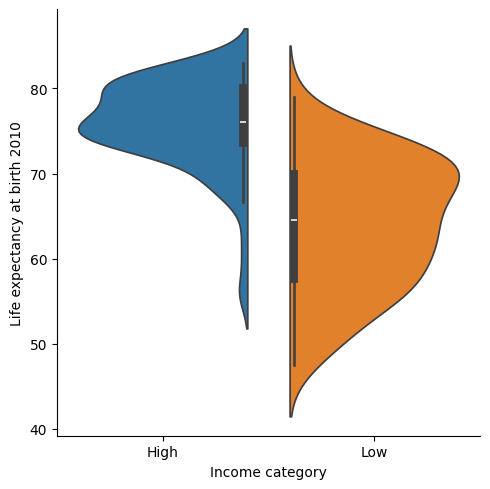

In [ ]:
from re import split
sns.catplot(data=world_data, kind='violin', x='Income category', y='Life expectancy at birth 2010', hue='Income category', split='True')

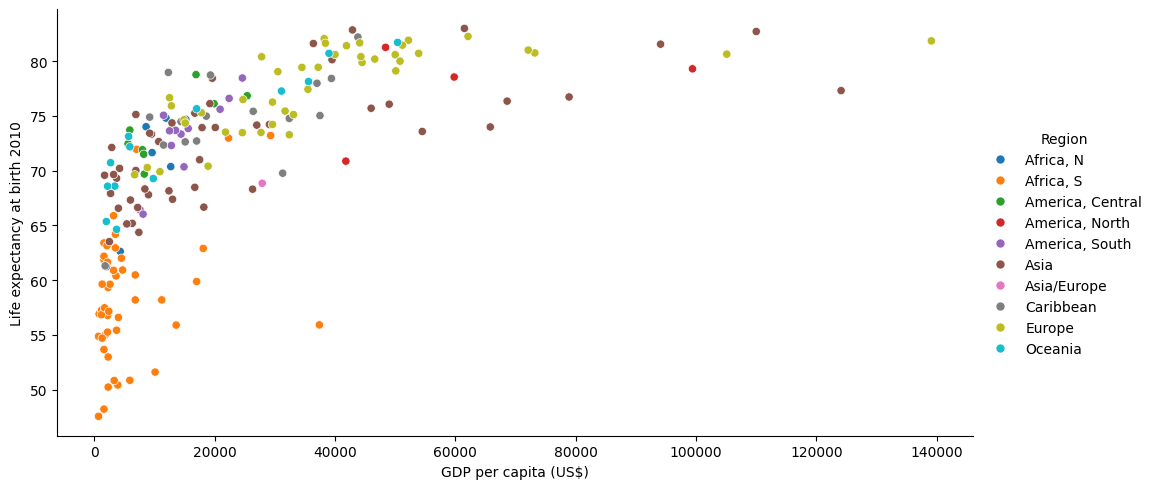

In [ ]:
sns.relplot(data=world_data, kind='scatter', x='GDP per capita (US$)', y='Life expectancy at birth 2010', hue='Region', aspect=2)

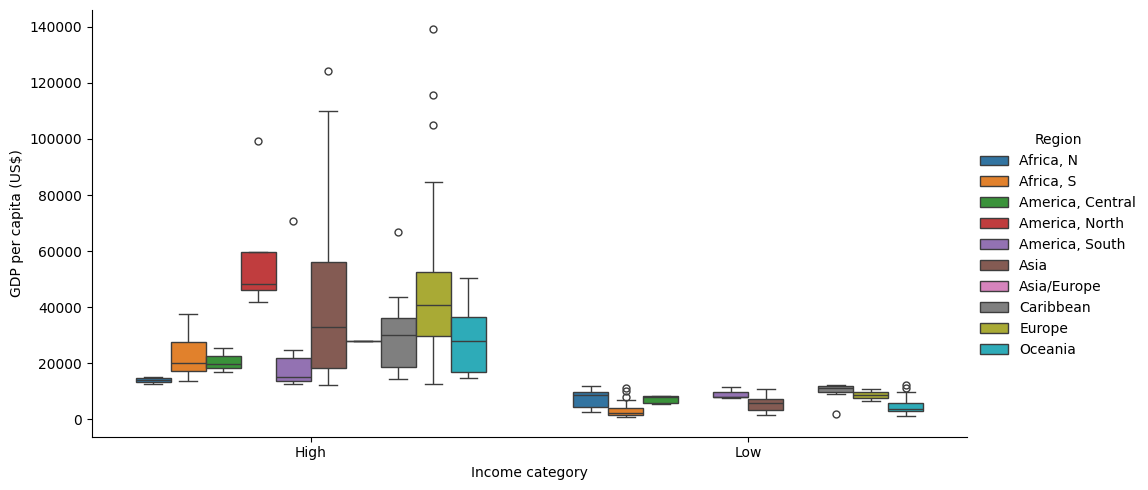

In [ ]:
sns.catplot(data=world_data, kind='box', x='Income category', y='GDP per capita (US$)', hue='Region', aspect=2)

## Communicating the results
## Checkpoint 1
> Use your analysis to answer the question: ***What are the differences between high and low income economies?***

# Exploring how life expectancy in high and low income economies changed since 1960

## Pre-processing the data
## Adding a new numeric feature
To explore the change in life expectancy you could add a feature that calculates the change in life expectancy.

> Run the code below to create a new feature `Life expectancy change 1960 to 2010` by subtracting the life expectancies in 1960 from those in 2010

In [ ]:
# subtract two columns and assign the answer to a new column
world_data['Life expectancy change 1960 to 2010'] = world_data['Life expectancy at birth 2010'] - world_data['Life expectancy at birth 1960']

# check the data
world_data

,no,Country,Region,population,birth rate per 1000,death rate per 1000,median age,labor force,unemployment (%),GDP per capita (US$),...,Total area,Land borders,Life expectancy at birth 1960,Life expectancy at birth 1970,Life expectancy at birth 1980,Life expectancy at birth 1990,Life expectancy at birth 2000,Life expectancy at birth 2010,Income category,Life expectancy change 1960 to 2010
0,1,Algeria,"Africa, N",41657488,21.5,4.3,28.3,11820000.0,11.7,15200.0,...,2381740,Yes,46.14,50.37,58.20,66.73,70.29,74.68,High,28.54
1,2,Egypt,"Africa, N",99413317,28.8,4.5,23.9,29950000.0,12.2,12700.0,...,1001450,Yes,48.06,52.16,58.34,64.58,68.61,70.36,High,22.30
2,3,Libya,"Africa, N",6754507,17.2,3.7,29.4,1114000.0,30.0,9600.0,...,1759540,Yes,42.61,56.05,64.19,68.52,70.47,71.64,Low,29.03
3,4,Morocco,"Africa, N",34314130,17.5,4.9,29.7,12000000.0,10.2,8600.0,...,446550,Yes,48.46,52.57,57.56,64.73,68.72,74.00,Low,25.54
4,5,Sudan,"Africa, N",43120843,34.2,6.7,17.9,11920000.0,19.6,4300.0,...,1861484,Yes,48.19,52.23,54.25,55.50,58.43,62.62,Low,14.43
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,232,Tokelau,Oceania,1285,NaN,NaN,NaN,440.0,NaN,1000.0,...,12,No,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN
232,233,Tonga,Oceania,106398,21.8,4.9,23.3,33800.0,1.1,5900.0,...,747,No,61.40,64.88,67.48,69.60,70.81,72.17,Low,10.77
233,234,Tuvalu,Oceania,11147,23.7,8.4,26.0,3615.0,NaN,3800.0,...,26,No,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN
234,235,Vanuatu,Oceania,288037,23.5,4.0,22.3,115900.0,1.7,2700.0,...,12189,No,46.44,52.37,58.35,63.07,67.44,70.72,Low,24.28


## Exploring the data

***How has life expectancy in high and low income economies changed since 1960?***

You could explore how has life expectancy changed since 1960 and whether life expectancy changed in the same way in high income countries and in low income countries?

You might want to:
* explore the new feature `Life expectancy change 1960 to 2010`;
* plot scatter diagrams using two different life expectancy columns, colour-coded by income category or region.

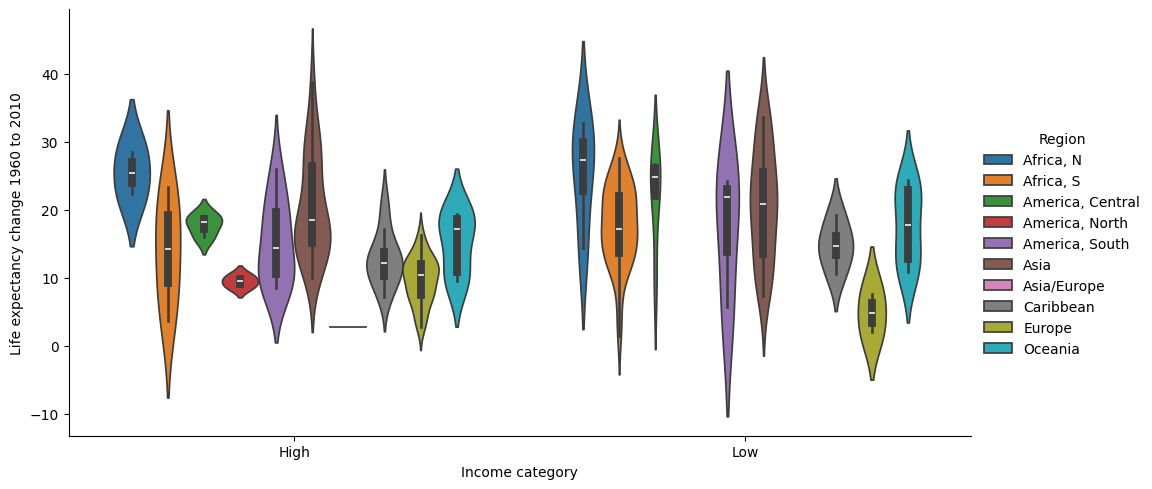

In [ ]:
sns.catplot(data=world_data, kind='violin', x='Income category', y='Life expectancy change 1960 to 2010', hue='Region', aspect=2)

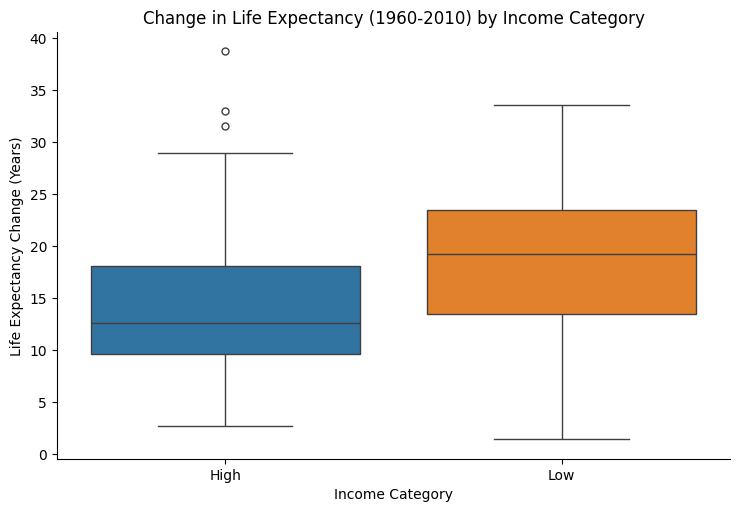

In [ ]:
import matplotlib.pyplot as plt

sns.catplot(data=world_data, kind='box', x='Income category', y='Life expectancy change 1960 to 2010', hue='Income category', aspect=1.5)
plt.title('Change in Life Expectancy (1960-2010) by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Life Expectancy Change (Years)')
plt.show()

## Communicating the results
## Checkpoint 2
> Use your analysis to answer the question: ***How has life expectancy changed in high and low income countries since 1960?***